# 04. Preprocesare si feature engineering

**Scop:** transformarea datelor brute (rezultate din EDA) in seturi gata pentru antrenarea modelelor ML predictive. Toate cele trei seturi (consum USA, pret Spania, solar India) trec prin acelasi pipeline modular, definit in `src/data_processing/preprocessing.py`.

**Pasi parcursi:**
1. Tratarea valorilor lipsa (interpolare liniara cu limita pe goluri lungi).
2. Eliminarea coloanelor "goale" (peste 60% NaN) - relevant pentru Spania.
3. Adaugarea de features temporale (ora, zi a saptamanii, luna, sarbatori, encoding ciclic).
4. Adaugarea de lag-uri (t-1, t-2, t-3, t-24, t-168) pentru target.
5. Adaugarea de rolling features (medie + deviatie standard pe ferestre 3h, 24h, 168h).
6. Split cronologic strict (train -> val -> test) fara shuffle, pentru a preveni leakage.

**De ce e important pentru disertatie:**
- Modelele ML pe serii temporale au nevoie de features informative; lag-urile si rolling-ul captureaza dependentele temporale.
- Encoding-ul ciclic (sin/cos) ajuta modelele liniare sa "inteleaga" ca ora 23 si ora 0 sunt vecine.
- Split cronologic = singura validare corecta pentru time series; shuffle-ul ar duce la rezultate iluzorii.

## Setup

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adaugam radacina proiectului in PYTHONPATH (necesar cand notebook-ul este intr-un subfolder)
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing.preprocessing import (
    handle_missing_values,
    add_temporal_features,
    add_lags,
    add_rolling_features,
    chronological_split,
    drop_empty_columns,
    build_features_consum_usa,
    build_features_pret_spania,
    build_features_solar_india,
)
from src.data_processing.loader import load_consum_usa, merge_solar, merge_spania
from src.utils.config_loader import load_config
from src.utils.plotting import setup_style, PALETA

setup_style()
warnings.filterwarnings("ignore", category=FutureWarning)

cfg = load_config()
P_CFG = cfg["preprocessing"]
print("Parametri preprocesare incarcati din config.yaml:")
for k, v in P_CFG.items():
    print(f"  {k}: {v}")

Parametri preprocesare incarcati din config.yaml:
  missing_strategy: interpolate
  max_nan_run: 24
  lags: [1, 2, 3, 24, 168]
  rolling_windows: [3, 24, 168]
  test_size: 0.2
  validation_size: 0.1
  holidays_country: {'consum_usa': 'US', 'pret_spania': 'ES', 'solar_india': 'IN'}
  solar_resample_to_hourly: True
  drop_column_nan_threshold: 0.6


## 1. Demo pas cu pas pe consum USA (PJME)

Pentru a intelege ce face fiecare functie, aplicam pasii unul cate unul pe setul de date PJME (consum orar in MW, perioada 2002-2018). La final aratam ca pipeline-ul `build_features_consum_usa` combina toti acesti pasi intr-un singur apel.

### 1.1. Incarcare date brute

In [2]:
df_raw = load_consum_usa()
print(f"Shape brut: {df_raw.shape}")
print(f"Range: {df_raw.index.min()} -> {df_raw.index.max()}")
print(f"NaN-uri in target: {df_raw['PJME_MW'].isna().sum()}")
df_raw.head()

Shape brut: (145362, 1)
Range: 2002-01-01 01:00:00 -> 2018-08-03 00:00:00
NaN-uri in target: 0


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


**Interpretare:** un singur target (`PJME_MW`), serie orara fara coloane suplimentare. Tot ce urmeaza adauga features derivate din index-ul temporal si din valorile target-ului.

### 1.2. Tratarea valorilor lipsa

In [3]:
df_step1 = handle_missing_values(
    df_raw,
    strategy=P_CFG["missing_strategy"],
    max_nan_run=P_CFG["max_nan_run"],
)
print(f"Shape dupa tratare NaN: {df_step1.shape}")
print(f"NaN ramase: {df_step1.isna().sum().sum()}")

Shape dupa tratare NaN: (145362, 1)
NaN ramase: 0


**Strategii disponibile** (configurabile prin `config.yaml`):
- `interpolate` (default): interpolare liniara intre puncte cunoscute, cu o limita de maxim 24 NaN consecutivi (peste care se face drop al randului) pentru a evita interpolari aiurea pe goluri lungi.
- `ffill`: forward fill (preia ultima valoare cunoscuta).
- `drop`: elimina randurile cu NaN.

Pentru PJME nu sunt NaN-uri, deci pasul nu schimba nimic. La Spania insa va fi crucial.

### 1.3. Features temporale

In [4]:
df_step2 = add_temporal_features(
    df_step1,
    cyclic_encoding=True,
    holidays_country="US",
)
print("Coloane noi adaugate:")
new_cols = [c for c in df_step2.columns if c not in df_step1.columns]
print(new_cols)
df_step2.head()

Coloane noi adaugate:
['hour', 'dayofweek', 'day', 'month', 'quarter', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_holiday']


,PJME_MW,hour,dayofweek,day,month,quarter,year,dayofyear,weekofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_holiday
Datetime,,,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,1,2002,1,1,0,0.258819,0.965926,0.781831,0.62349,0.0,1.0,1
2002-01-01 02:00:00,29265.0,2,1,1,1,1,2002,1,1,0,0.500000,0.866025,0.781831,0.62349,0.0,1.0,1
2002-01-01 03:00:00,28357.0,3,1,1,1,1,2002,1,1,0,0.707107,0.707107,0.781831,0.62349,0.0,1.0,1
2002-01-01 04:00:00,27899.0,4,1,1,1,1,2002,1,1,0,0.866025,0.500000,0.781831,0.62349,0.0,1.0,1
2002-01-01 05:00:00,28057.0,5,1,1,1,1,2002,1,1,0,0.965926,0.258819,0.781831,0.62349,0.0,1.0,1


**Ce am adaugat:**
- `hour`, `dayofweek`, `day`, `month`, `quarter`, `year`, `dayofyear`, `weekofyear` - features clasice care surprind sezonalitatea zilnica, saptamanala si anuala.
- `is_weekend` (0/1) - consumul difera mult intre weekend si zile lucratoare.
- `is_holiday` (0/1) - foloseste pachetul `holidays` cu sarbatorile US (Thanksgiving, Independence Day etc.).
- `hour_sin` / `hour_cos`, `dow_sin` / `dow_cos`, `month_sin` / `month_cos` - encoding ciclic.

**De ce encoding ciclic?** Daca modelul vede `hour=23` si `hour=0`, le considera la distanta 23. Dar in realitate sunt vecine (orele 23 si 24). Sin/cos plaseaza aceste valori pe un cerc, deci distanta euclidiana reflecta vecinatatea reala.

**Vizualizare encoding ciclic** - toate orele unei zile pe un cerc unitate:

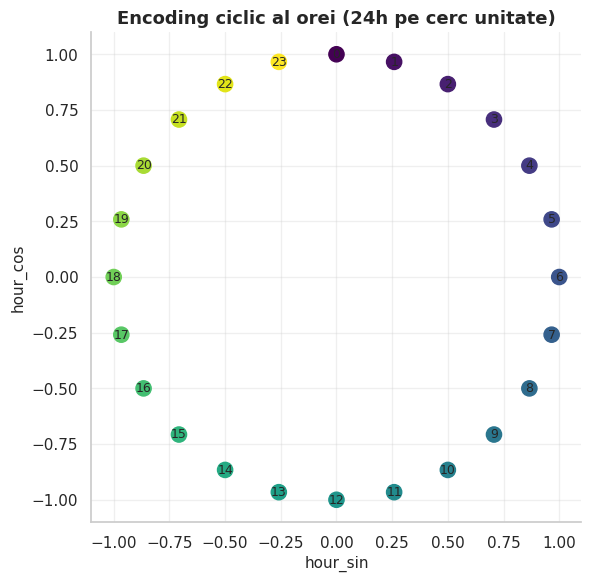

In [5]:
sample = df_step2.iloc[:24]
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample["hour_sin"], sample["hour_cos"], c=sample["hour"], cmap="viridis", s=120)
for _, row in sample.iterrows():
    ax.annotate(int(row["hour"]), (row["hour_sin"], row["hour_cos"]), fontsize=9, ha="center", va="center")
ax.set_title("Encoding ciclic al orei (24h pe cerc unitate)")
ax.set_xlabel("hour_sin")
ax.set_ylabel("hour_cos")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare grafic:** orele formeaza un cerc, iar ora 23 e vecina cu ora 0 - exact ce vrem sa inteleaga modelul.

### 1.4. Lag-uri pe target

In [6]:
df_step3 = add_lags(
    df_step2,
    target="PJME_MW",
    lags=P_CFG["lags"],
)
lag_cols = [c for c in df_step3.columns if "lag" in c]
print("Lag-uri adaugate:", lag_cols)
df_step3[["PJME_MW"] + lag_cols].head(10)

Lag-uri adaugate: ['PJME_MW_lag_1', 'PJME_MW_lag_2', 'PJME_MW_lag_3', 'PJME_MW_lag_24', 'PJME_MW_lag_168']


,PJME_MW,PJME_MW_lag_1,PJME_MW_lag_2,PJME_MW_lag_3,PJME_MW_lag_24,PJME_MW_lag_168
Datetime,,,,,,
2002-01-01 01:00:00,30393.0,NaN,NaN,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,30393.0,NaN,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,29265.0,30393.0,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,28357.0,29265.0,30393.0,NaN,NaN
2002-01-01 05:00:00,28057.0,27899.0,28357.0,29265.0,NaN,NaN
2002-01-01 06:00:00,28654.0,28057.0,27899.0,28357.0,NaN,NaN
2002-01-01 07:00:00,29308.0,28654.0,28057.0,27899.0,NaN,NaN
2002-01-01 08:00:00,29595.0,29308.0,28654.0,28057.0,NaN,NaN
2002-01-01 09:00:00,29943.0,29595.0,29308.0,28654.0,NaN,NaN


**Logica:**
- `PJME_MW_lag_1` = consumul de acum 1 ora.
- `PJME_MW_lag_24` = consumul de acum 24 ore (acelasi moment, ziua precedenta).
- `PJME_MW_lag_168` = consumul de acum 168 ore = 7 zile (acelasi moment, saptamana trecuta).

Aceste lag-uri sunt extrem de informative pentru consumul electric, care e foarte ciclic zilnic si saptamanal. Primele 168 randuri vor avea NaN si vor fi eliminate la final.

### 1.5. Rolling features

In [7]:
df_step4 = add_rolling_features(
    df_step3,
    target="PJME_MW",
    windows=P_CFG["rolling_windows"],
    stats=("mean", "std"),
)
roll_cols = [c for c in df_step4.columns if "roll" in c]
print("Rolling features adaugate:", roll_cols)
df_step4[["PJME_MW"] + roll_cols].head(10)

Rolling features adaugate: ['PJME_MW_roll_mean_3', 'PJME_MW_roll_std_3', 'PJME_MW_roll_mean_24', 'PJME_MW_roll_std_24', 'PJME_MW_roll_mean_168', 'PJME_MW_roll_std_168']


,PJME_MW,PJME_MW_roll_mean_3,PJME_MW_roll_std_3,PJME_MW_roll_mean_24,PJME_MW_roll_std_24,PJME_MW_roll_mean_168,PJME_MW_roll_std_168
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,29829.000000,797.616449,NaN,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,29338.333333,1019.979085,NaN,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,28507.000000,695.243842,NaN,NaN,NaN,NaN
2002-01-01 06:00:00,28654.0,28104.333333,232.639922,NaN,NaN,NaN,NaN
2002-01-01 07:00:00,29308.0,28203.333333,398.203884,NaN,NaN,NaN,NaN
2002-01-01 08:00:00,29595.0,28673.000000,625.716389,NaN,NaN,NaN,NaN
2002-01-01 09:00:00,29943.0,29185.666667,482.280347,NaN,NaN,NaN,NaN


**Atentie la data leakage!** Rolling-ul se aplica pe seria SHIFTATA cu 1 pas (`target.shift(1)`) - asta inseamna ca media rolling de 24h la momentul t **NU include** valoarea y_t (pe care vrem sa o prezicem). Acest detaliu este implementat in `add_rolling_features`.

### 1.6. Vizualizare lag + rolling pe o saptamana

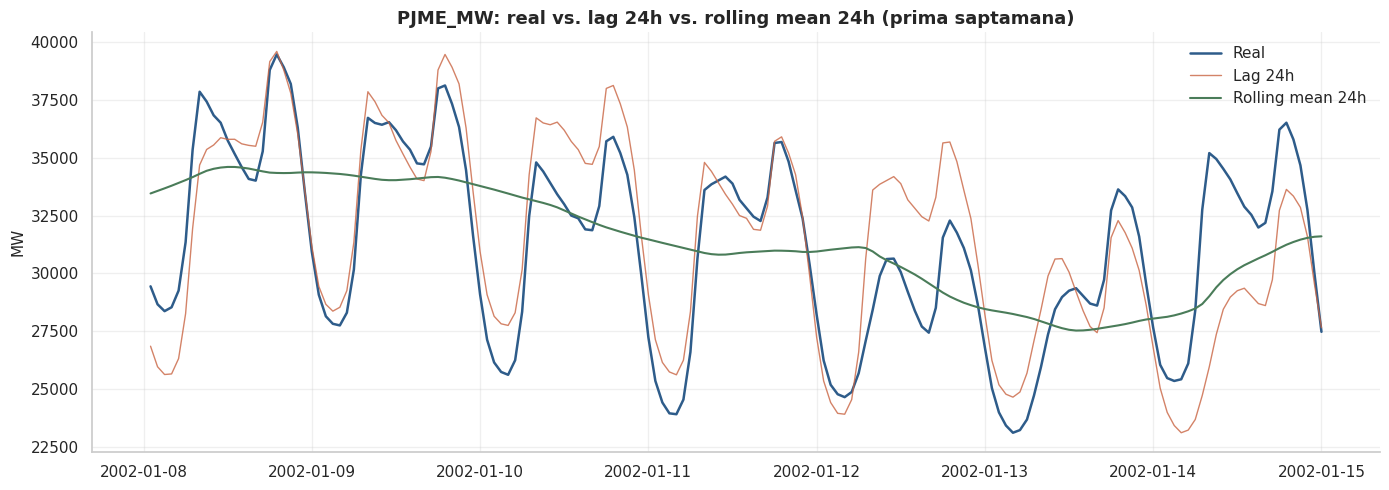

In [8]:
one_week = df_step4.dropna().iloc[:168]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(one_week.index, one_week["PJME_MW"], label="Real", color=PALETA["primary"], lw=1.8)
ax.plot(one_week.index, one_week["PJME_MW_lag_24"], label="Lag 24h", color=PALETA["secondary"], lw=1.0, alpha=0.8)
ax.plot(one_week.index, one_week["PJME_MW_roll_mean_24"], label="Rolling mean 24h", color=PALETA["tertiary"], lw=1.5)
ax.set_title("PJME_MW: real vs. lag 24h vs. rolling mean 24h (prima saptamana)")
ax.set_ylabel("MW")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare:** lag 24h aproape coincide cu real (consumul e foarte ciclic zilnic), iar rolling mean netezeste oscilatiile. Aceste 3 serii devin features puternice pentru modelele ML.

## 2. Pipeline complet pentru consum USA

`build_features_consum_usa()` ruleaza toti pasii intr-un singur apel, cu parametrii din `config.yaml`.

In [9]:
df_usa = build_features_consum_usa(config=cfg)
print(f"Shape final: {df_usa.shape}")
print(f"NaN total: {df_usa.isna().sum().sum()}")
print(f"Range: {df_usa.index.min()} -> {df_usa.index.max()}")
print(f"\nColoane finale ({df_usa.shape[1]}):")
print(list(df_usa.columns))

Shape final: (145194, 28)
NaN total: 0
Range: 2002-01-08 01:00:00 -> 2018-08-03 00:00:00

Coloane finale (28):
['PJME_MW', 'hour', 'dayofweek', 'day', 'month', 'quarter', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_holiday', 'PJME_MW_lag_1', 'PJME_MW_lag_2', 'PJME_MW_lag_3', 'PJME_MW_lag_24', 'PJME_MW_lag_168', 'PJME_MW_roll_mean_3', 'PJME_MW_roll_std_3', 'PJME_MW_roll_mean_24', 'PJME_MW_roll_std_24', 'PJME_MW_roll_mean_168', 'PJME_MW_roll_std_168']


### 2.1. Split cronologic train / val / test

In [10]:
split_usa = chronological_split(
    df_usa,
    target="PJME_MW",
    test_size=P_CFG["test_size"],
    validation_size=P_CFG["validation_size"],
)
print(f"Train: {split_usa['X_train'].shape}, perioada: {split_usa['X_train'].index.min()} -> {split_usa['X_train'].index.max()}")
print(f"Val:   {split_usa['X_val'].shape}, perioada: {split_usa['X_val'].index.min()} -> {split_usa['X_val'].index.max()}")
print(f"Test:  {split_usa['X_test'].shape}, perioada: {split_usa['X_test'].index.min()} -> {split_usa['X_test'].index.max()}")

Train: (101637, 27), perioada: 2002-01-08 01:00:00 -> 2013-08-13 21:00:00
Val:   (14519, 27), perioada: 2013-08-13 22:00:00 -> 2015-04-10 23:00:00
Test:  (29038, 27), perioada: 2015-04-11 00:00:00 -> 2018-08-03 00:00:00


**De retinut:** `shuffle=False`, splitting pur cronologic. Modelele invata pe trecut si sunt validate pe viitor - exact cum se face in productie.

### 2.2. Vizualizare split pe timeline

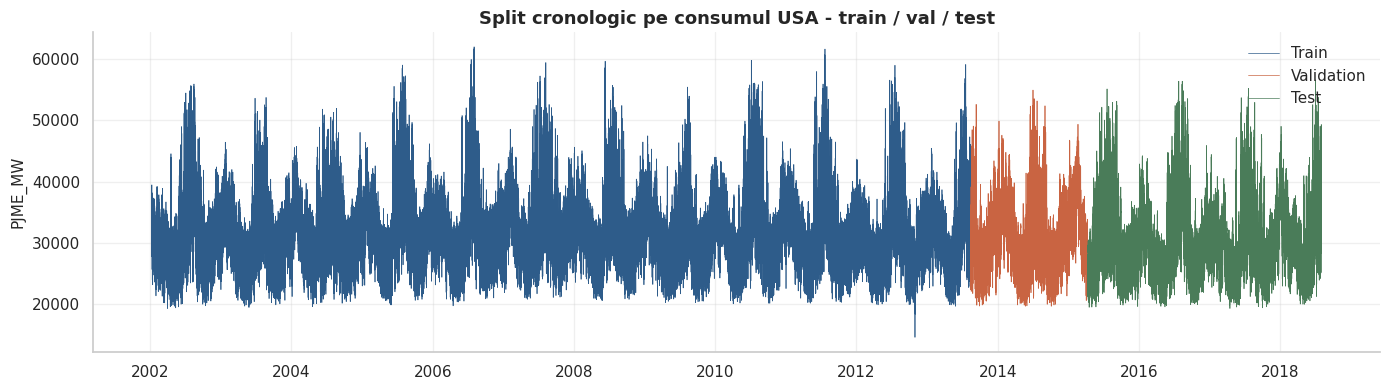

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
y = df_usa["PJME_MW"]
ax.plot(split_usa["y_train"].index, split_usa["y_train"], color=PALETA["primary"], lw=0.5, label="Train")
ax.plot(split_usa["y_val"].index, split_usa["y_val"], color=PALETA["secondary"], lw=0.5, label="Validation")
ax.plot(split_usa["y_test"].index, split_usa["y_test"], color=PALETA["tertiary"], lw=0.5, label="Test")
ax.set_title("Split cronologic pe consumul USA - train / val / test")
ax.set_ylabel("PJME_MW")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Pipeline pentru pret Spania

Setul Spania e mai complex: 28 surse de generare + meteo Madrid + cerere + pret. Pipeline-ul include un pas suplimentar - eliminarea coloanelor cu prea multi NaN (unele surse de generare lipsesc complet).

In [12]:
df_es_raw = merge_spania(city="Madrid")
print(f"Shape brut: {df_es_raw.shape}")
nan_per_col = df_es_raw.isna().mean().sort_values(ascending=False).head(10)
print(f"\nTop 10 coloane cu cele mai multe NaN-uri (procent):")
print(nan_per_col)

Shape brut: (35064, 44)

Top 10 coloane cu cele mai multe NaN-uri (procent):
forecast wind offshore eday ahead              1.000000
generation hydro pumped storage aggregated     1.000000
total load actual                              0.001027
generation waste                               0.000542
generation marine                              0.000542
generation hydro run-of-river and poundage     0.000542
generation hydro pumped storage consumption    0.000542
generation biomass                             0.000542
generation fossil oil                          0.000542
generation geothermal                          0.000513
dtype: float64


In [13]:
df_es = build_features_pret_spania(config=cfg)
print(f"Shape final: {df_es.shape}")
print(f"NaN ramase: {df_es.isna().sum().sum()}")
print(f"\nTarget: 'price actual', perioada: {df_es.index.min()} -> {df_es.index.max()}")

Shape final: (34896, 65)
NaN ramase: 0

Target: 'price actual', perioada: 2015-01-07 23:00:00 -> 2018-12-31 22:00:00


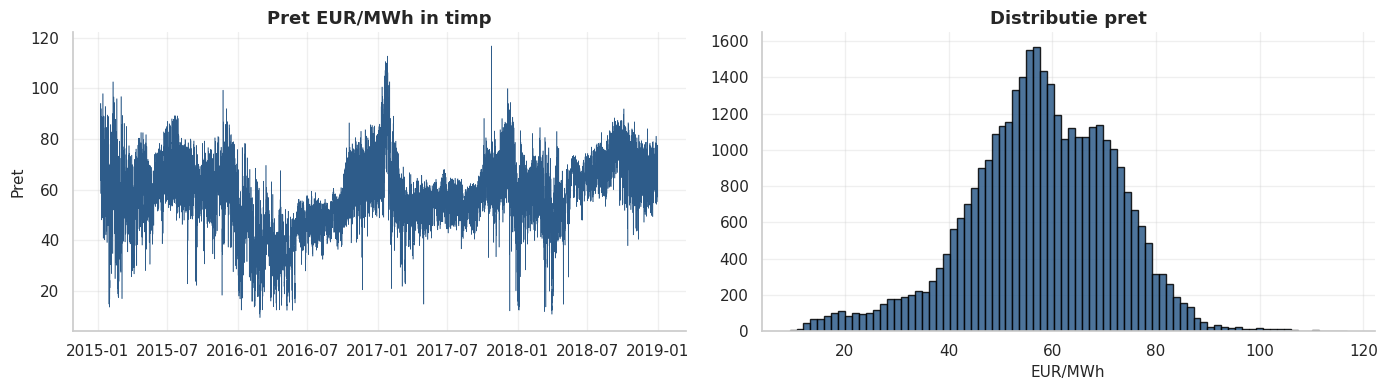

In [14]:
# Vizualizare distributie target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df_es.index, df_es["price actual"], color=PALETA["primary"], lw=0.4)
axes[0].set_title("Pret EUR/MWh in timp")
axes[0].set_ylabel("Pret")
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_es["price actual"], bins=80, color=PALETA["primary"], edgecolor="black", alpha=0.85)
axes[1].set_title("Distributie pret")
axes[1].set_xlabel("EUR/MWh")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare:** pretul oscileaza de la valori negative (rare, exces de generare regenerabila) pana la peste 100 EUR/MWh. Modelul va trebui sa invete sa surprinda atat tendinta lunga cat si volatilitatea pe termen scurt.

## 4. Pipeline pentru solar India

Setul solar are doua particularitati:
- Granularitate originala 15 min - pipeline-ul resampleaza la orar (configurabil prin `solar_resample_to_hourly`).
- Perioada scurta (34 zile) - lag-ul de saptamana (168) elimina prima saptamana din date.

In [15]:
df_in_raw = merge_solar()
print(f"Shape brut (15-min): {df_in_raw.shape}")
print(f"Range: {df_in_raw.index.min()} -> {df_in_raw.index.max()}")

Shape brut (15-min): (3157, 7)
Range: 2020-05-15 00:00:00 -> 2020-06-17 23:45:00


In [16]:
df_in = build_features_solar_india(config=cfg)
print(f"Shape final (orar): {df_in.shape}")
print(f"NaN ramase: {df_in.isna().sum().sum()}")
print(f"Coloane cheie: {[c for c in df_in.columns if c in ['DC_POWER', 'AC_POWER', 'IRRADIATION', 'MODULE_TEMPERATURE']]}")

Shape final (orar): (648, 34)
NaN ramase: 0
Coloane cheie: ['DC_POWER', 'AC_POWER', 'MODULE_TEMPERATURE', 'IRRADIATION']


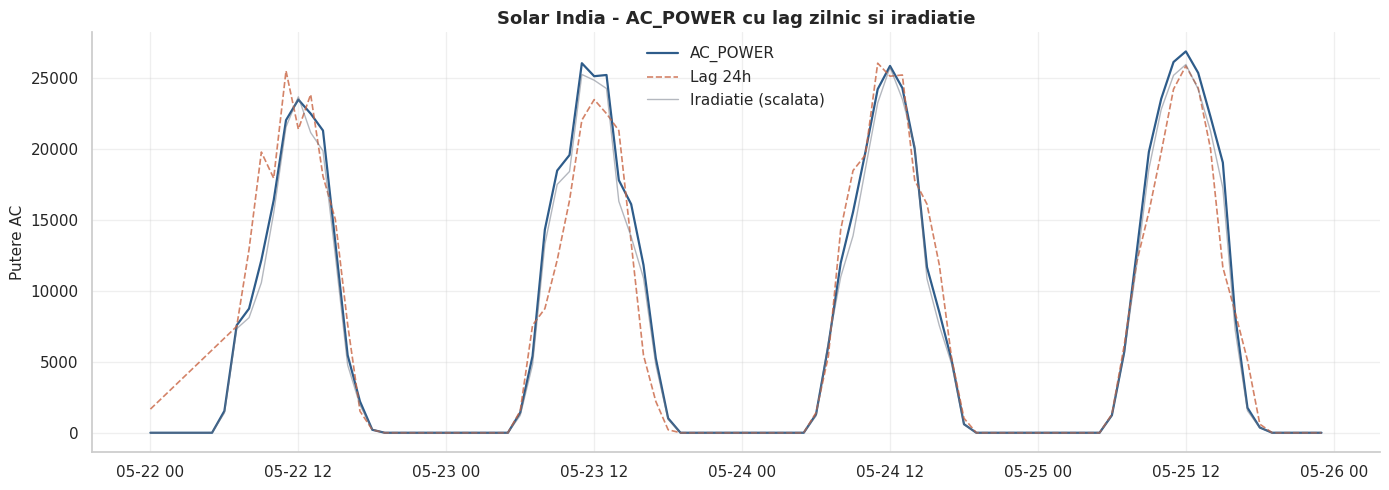

In [17]:
# Plot AC_POWER cu lag 24h pe cateva zile
sample_in = df_in.iloc[:96]  # 4 zile
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_in.index, sample_in["AC_POWER"], label="AC_POWER", color=PALETA["primary"], lw=1.6)
ax.plot(sample_in.index, sample_in["AC_POWER_lag_24"], label="Lag 24h", color=PALETA["secondary"], lw=1.2, alpha=0.8, ls="--")
ax.plot(sample_in.index, sample_in["IRRADIATION"] * df_in["AC_POWER"].max(), label="Iradiatie (scalata)", color=PALETA["neutral"], lw=1.0, alpha=0.5)
ax.set_title("Solar India - AC_POWER cu lag zilnic si iradiatie")
ax.set_ylabel("Putere AC")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare:** generarea solara este puternic corelata cu iradiatia (curba zilnica) si foarte ciclica zi-de-zi (lag 24 e aproape perfect aliniat cu real). Asta sugereaza ca modelele simple (Linear, RF) ar putea performa bine, mai ales daca au accesul la features-ul `IRRADIATION`.

## 5. Sanity checks finale

Verificari programatice ca pipeline-ul produce date corecte pentru ML:
1. Zero NaN in toate seturile.
2. Split cronologic strict (train < val < test).
3. Encoding ciclic in domeniul corect [-1, 1].
4. Numar de features rezonabil per set.

In [18]:
def sanity_check(name, df, target):
    sp = chronological_split(df, target=target,
                             test_size=P_CFG["test_size"],
                             validation_size=P_CFG["validation_size"])
    nan_ok = df.isna().sum().sum() == 0
    chrono_ok = sp["X_train"].index[-1] < sp["X_val"].index[0] < sp["X_test"].index[0]
    sin_ok = (df["hour_sin"].between(-1, 1).all() and df["hour_cos"].between(-1, 1).all())
    no_target_in_features = target not in sp["X_train"].columns
    return {
        "set": name,
        "rows": df.shape[0],
        "features": df.shape[1] - 1,
        "nan_zero": nan_ok,
        "chronologic": chrono_ok,
        "sin_in_range": sin_ok,
        "target_excluded": no_target_in_features,
    }

results = [
    sanity_check("Consum USA", df_usa, "PJME_MW"),
    sanity_check("Pret Spania", df_es, "price actual"),
    sanity_check("Solar India", df_in, "AC_POWER"),
]
pd.DataFrame(results).set_index("set")

,rows,features,nan_zero,chronologic,sin_in_range,target_excluded
set,,,,,,
Consum USA,145194,27,True,True,True,True
Pret Spania,34896,64,True,True,True,True
Solar India,648,33,True,True,True,True


## 6. Salvare date procesate (parquet)

Salvam DataFrame-urile finale in `data/processed/` ca sa nu mai rulam pipeline-ul de fiecare data cand antrenam un model. Format `parquet` - compact si pastreaza tipurile.

In [19]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

df_usa.to_parquet(processed_dir / "consum_usa_features.parquet")
df_es.to_parquet(processed_dir / "pret_spania_features.parquet")
df_in.to_parquet(processed_dir / "solar_india_features.parquet")

for f in sorted(processed_dir.glob("*.parquet")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}: {size_kb:.1f} KB")

  consum_usa_features.parquet: 10337.4 KB
  pret_spania_features.parquet: 4309.4 KB
  solar_india_features.parquet: 96.2 KB


## 7. Concluzii

- Pipeline-ul modular din `src/data_processing/preprocessing.py` aplica acelasi flux pe toate cele 3 seturi de date, cu parametrizari minime per set (target, oras meteo, frecventa).
- **Consum USA**: 145.194 randuri orare 2002-2018, 27 features. Cel mai bogat istoric, ideal pentru forecasting pe orizonturi medii.
- **Pret Spania**: 34.896 randuri orare 2015-2018, 64 features (inclusiv 28 surse generare + meteo). Cel mai complex, util pentru optimizare battery dispatch.
- **Solar India**: 648 randuri orare (34 zile), 33 features. Set scurt dar dens, pentru optimizare panouri si validare rapida.

**Toate seturile au:** zero NaN, split cronologic strict, target exclus din features, encoding ciclic.

**Pas urmator:** notebook 05 - antrenare si comparare modele ML predictive (Linear, RF, XGBoost, LSTM).